In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from math import floor, ceil

df = pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
colunasSensiveis = ["age", "fnlwgt", "capital.gain", "capital.loss"]

In [4]:
def anonimizacao(valor, variacaoMax = 0.2, variacaoMin = 0.1):
    if(pd.isnull(valor) or valor == 0): return np.nan # Remoção
    randomMenor = np.random.uniform(variacaoMin, variacaoMax) # Perturbacao
    randomMaior = np.random.uniform(variacaoMin, variacaoMax)
    valorMenor = int(floor(valor * (1 - randomMenor) / 10) * 10)
    valorMaior = int(ceil(valor * (1 + randomMaior) / 10) * 10)
    return f"{valorMenor} - {valorMaior}"

In [5]:
for col in colunasSensiveis:
    df[col] = df[col].apply(anonimizacao)

print(df)

            age workclass           fnlwgt     education  education.num  \
0      70 - 110         ?    64480 - 90690       HS-grad              9   
1      60 - 100   Private  114450 - 152300       HS-grad              9   
2       50 - 80         ?  152830 - 218800  Some-college             10   
3       40 - 60   Private  119490 - 166070       7th-8th              4   
4       30 - 50   Private  225260 - 302660  Some-college             10   
...         ...       ...              ...           ...            ...   
32556   10 - 30   Private  249980 - 350450  Some-college             10   
32557   20 - 40   Private  208800 - 302240    Assoc-acdm             12   
32558   30 - 50   Private  133630 - 173640       HS-grad              9   
32559   40 - 70   Private  125830 - 175410       HS-grad              9   
32560   10 - 30   Private  167830 - 231920       HS-grad              9   

           marital.status         occupation   relationship   race     sex  \
0                 Wid

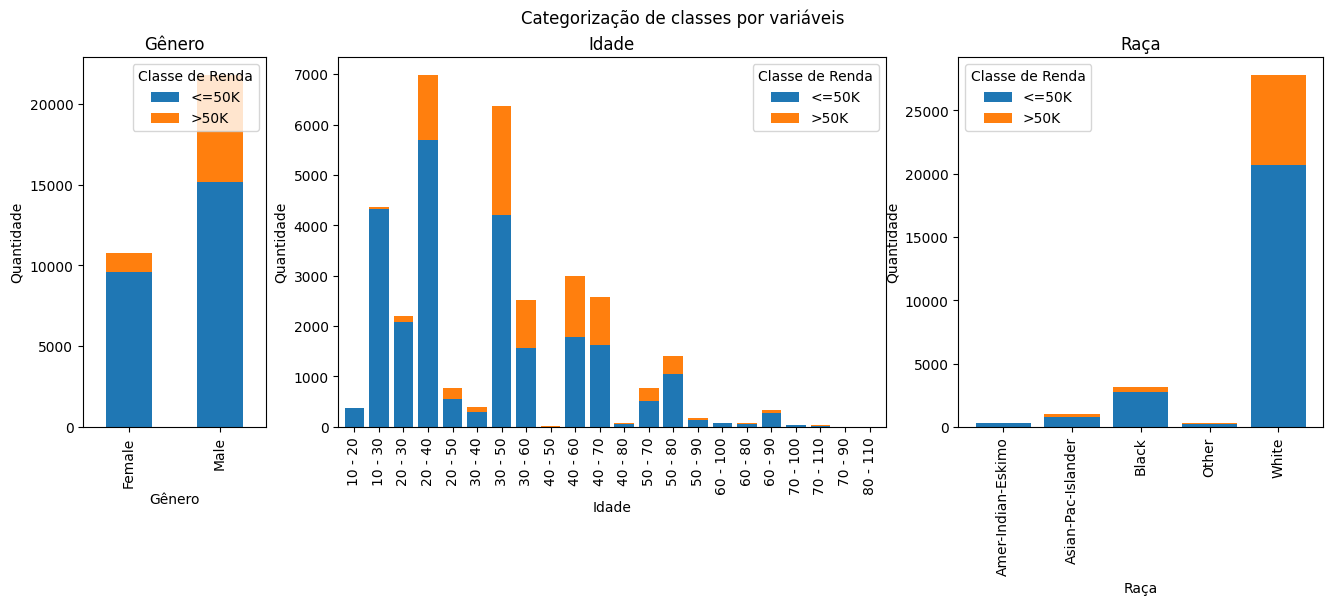

In [6]:
fig, ax = plt.subplots(1, 3, width_ratios=[1, 3, 2])
fig.set_figwidth(16)
fig.suptitle("Categorização de classes por variáveis")

sex_income = df.groupby(['sex', 'income']).size().unstack()
sex_income.plot(kind='bar', stacked=True, ax=ax[0])
ax[0].set_title('Gênero')
ax[0].set_xlabel('Gênero')
ax[0].set_ylabel('Quantidade')
ax[0].legend(title='Classe de Renda')

age_income = df.groupby(['age','income']).size().unstack()
age_income.plot(kind='bar', stacked=True, width=0.8, ax=ax[1])
ax[1].set_title('Idade')
ax[1].set_xlabel('Idade')
ax[1].set_ylabel('Quantidade')
ax[1].legend(title='Classe de Renda')

race_income = df.groupby(['race', 'income']).size().unstack()
race_income.plot(kind='bar', stacked=True, width=0.8, ax=ax[2])
ax[2].set_title('Raça')
ax[2].set_xlabel('Raça')
ax[2].set_ylabel('Quantidade')
ax[2].legend(title='Classe de Renda')

plt.show()

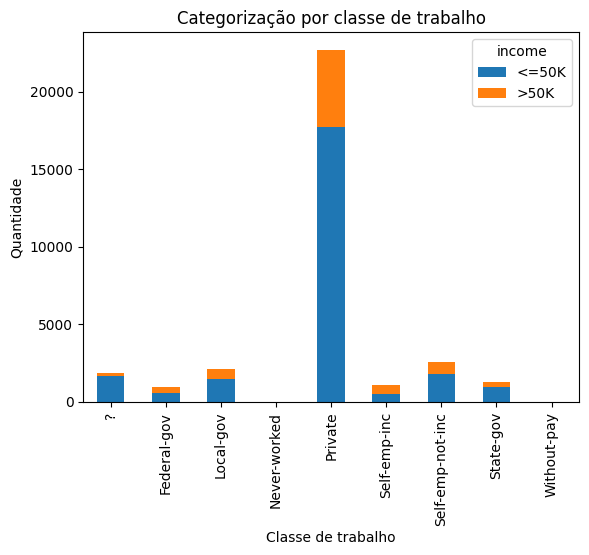

In [10]:
work_income = df.groupby(['workclass', 'income']).size().unstack()
work_income.plot(kind='bar', stacked=True)
plt.title("Categorização por classe de trabalho")
plt.xlabel("Classe de trabalho")
plt.ylabel("Quantidade")
plt.show()

Para essa atividade, escolhemos o dataset de "Adult Census Income", disponível na plataforma Kaggle. Esse dataset possui informações de uma população para prever se a renda de uma pessoa ultrapassa de 50 mil dólares ao ano. Precisávamos pegar essa base de dados e anonimizar informações sensíveis que poderiam ser utilizadas para identificar essas pessoas. Não conseguimos identificar muitas colunas que necessitavam de anonimização de dados, porém deduzimos que as colunas "age", "fnlwgt", "capital.gain" e "capital.loss" necessitavam de um certo nível de anonimização.  
  
Para fazer a anonimização dos dados, decidimos escolher o método de anonimização por perturbação para dados em que sejam impossíveis de possuir valores diferentes de 0, como idade, que seria o ponto fraco desse método devido à forma de como implementamos, e para esses casos especiais, efetuamos a remoção desses valores, substituindo o valor inteiro para um valor nulo. Devido à forma de como desenvolvemos o código, os gráficos de categorização dos dados, principalmente o de idade, ficou com valores que poderiam ser agrupados. Priorizamos utilizar o dataframe anonimizado para maior segurança, porém trouxe esse problema de dados sem sentido nos gráficos, por exemplo, duas colunas diferentes com valores que poderiam ser agrupados em um só, por exemplo, 70 - 100 e 70 - 110.  
  
Pelos dados que conseguimos analisar, através dos gráficos plotados, a maioria das pessoas da base de dados são do sexo masculino, e existem mais pessoas com idade entre 30 a 50 anos, sendo que pessoas entre 30 a 50 anos maior quantidade de pessoas com classe de renda maior que 50 mil. A raça predominante é a branca e a maioria das pessoas possuem uma classe de trabalho privada.